In [1]:
from pathlib import Path
from google.colab import drive
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:

nombre_imagen_simplicidad = "sv_001.jpeg"

# Carpeta donde esta guardada la imagen en Drive
ruta_carpeta = Path(
    "/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/TP_006/TP 006/IMAGENES/ORIGINALES"
)


ruta_imagen_simplicidad = ruta_carpeta / nombre_imagen_simplicidad

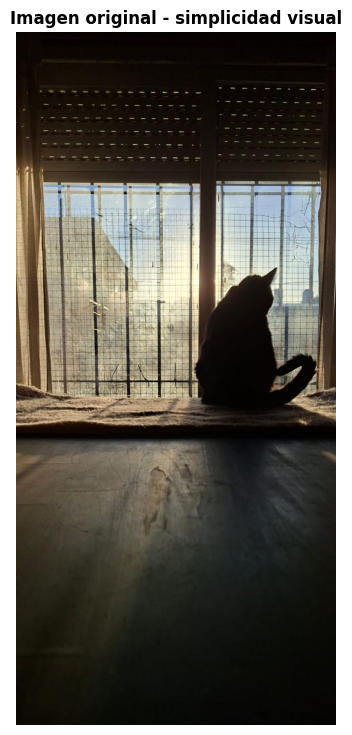

In [4]:
def cargar_rgb(ruta):
    """
    Abre una imagen color con OpenCV y la devuelve en formato RGB.
    OpenCV lee por defecto en BGR, por eso se convierte a RGB
    para visualizar correctamente con Matplotlib.
    """

    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

    return imagen_rgb


# Cargamos la imagen original
imagen_simplicidad_rgb = cargar_rgb(ruta_imagen_simplicidad)


# Mostramos la imagen original
plt.figure(figsize=(6, 9))
plt.imshow(imagen_simplicidad_rgb)
plt.title("Imagen original - simplicidad visual", fontweight="bold")
plt.axis("off")
plt.show()


El contraluz permitió simplificar visualmente la escena y separar claramente al sujeto del fondo. La silueta reduce el nivel de detalle y dirige la atención hacia la forma general del animal y la atmósfera construida por la luz.

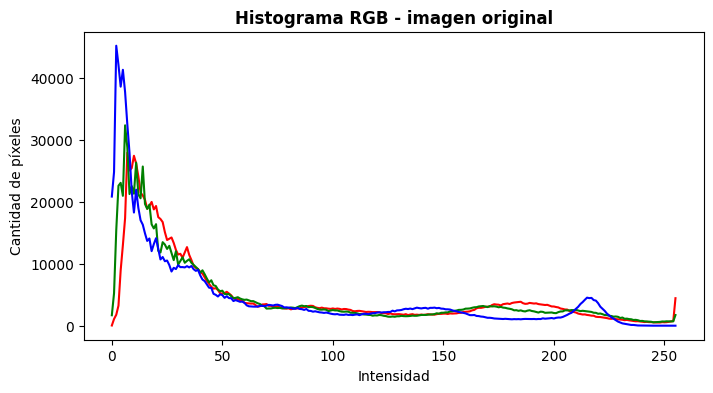

In [5]:
plt.figure(figsize=(8, 4))

# En una imagen RGB, los canales son:
# 0 = rojo, 1 = verde, 2 = azul.
colores = ("red", "green", "blue")

for i, color in enumerate(colores):

    histograma = cv2.calcHist(
        [imagen_simplicidad_rgb],  # imagen
        [i],                       # canal
        None,                      # sin mascara
        [256],                     # cantidad de bins
        [0, 256]                   # rango de intensidades
    )

    plt.plot(histograma, color=color)

plt.title("Histograma RGB - imagen original", fontweight="bold")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")
plt.show()


El histograma de la imagen original muestra una fuerte concentración de píxeles en intensidades bajas, especialmente entre los valores 0 y 40. Esto indica un predominio de zonas oscuras generado por el contraluz y las sombras presentes en la escena.

Los tres canales RGB presentan comportamientos similares, aunque el canal azul posee un pico más pronunciado en las bajas intensidades debido a la iluminación fría proveniente de la ventana.

También se observa una menor cantidad de píxeles en intensidades altas, correspondientes principalmente a las zonas iluminadas del exterior y los reflejos de la luz natural.

La distribución general evidencia un contraste marcado entre sombras profundas y áreas muy iluminadas, característica típica de escenas tomadas en contraluz.

Conversión a escala de grises

La imagen se convierte a escala de grises para eliminar la información cromática y centrar la atención en la forma, el contraste y la relación entre luces y sombras. Esta operación favorece una lectura más simple y directa de la composición.

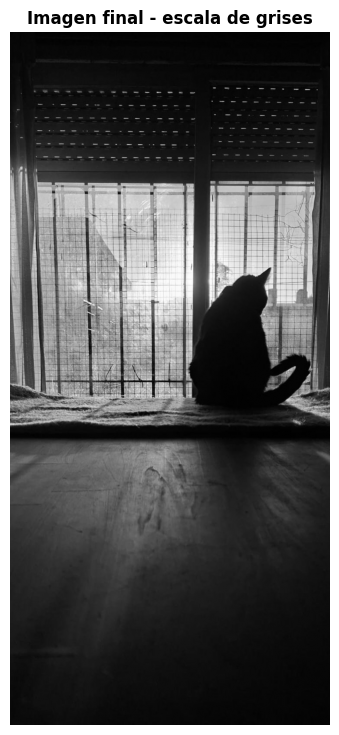

In [6]:

imagen_simplicidad_gris = cv2.cvtColor(
    imagen_simplicidad_rgb,
    cv2.COLOR_RGB2GRAY
)



plt.figure(figsize=(6, 9))
plt.imshow(imagen_simplicidad_gris, cmap="gray")
plt.title("Imagen final - escala de grises", fontweight="bold")
plt.axis("off")
plt.show()


Al eliminar el color, la silueta del sujeto se vuelve más dominante y el contraluz adquiere mayor protagonismo visual.

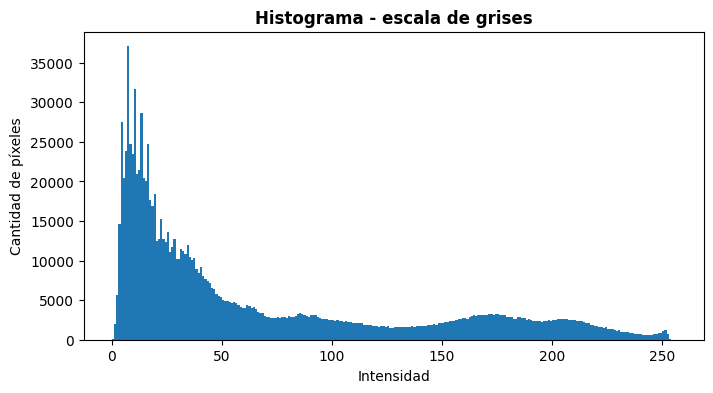

In [7]:
plt.figure(figsize=(8, 4))

plt.hist(
    imagen_simplicidad_gris.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title("Histograma - escala de grises", fontweight="bold")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")
plt.show()



El histograma en escala de grises muestra la distribución de luminosidad luego de eliminar la información de color. La concentración de valores oscuros refleja el predominio de sombras y la presencia de un fuerte contraluz.

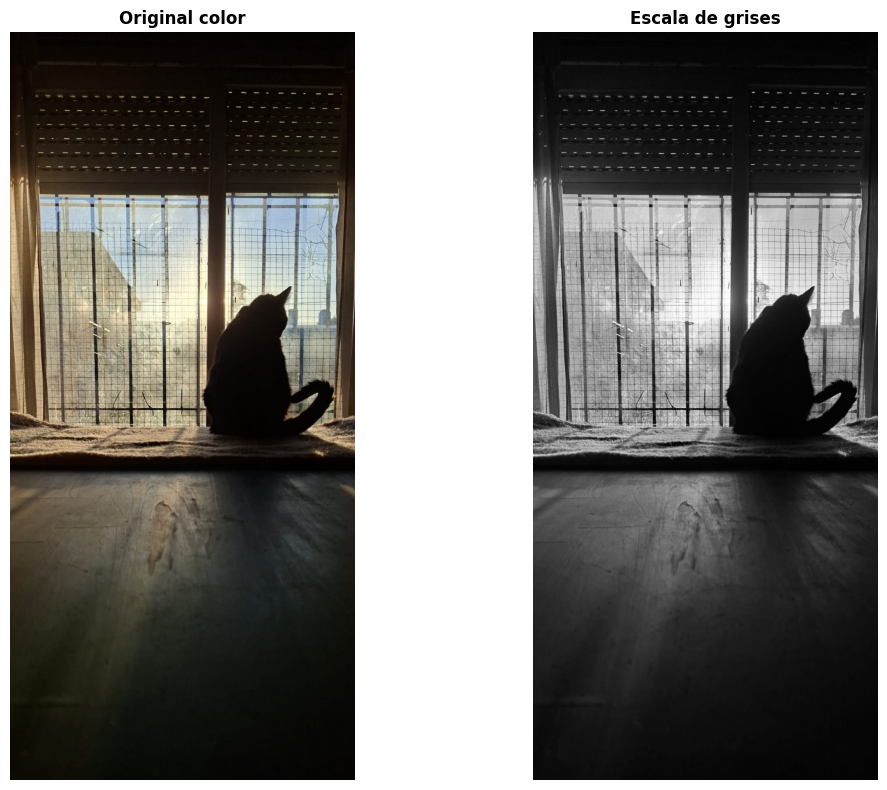

In [8]:
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(imagen_simplicidad_rgb)
plt.title("Original color", fontweight="bold")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_simplicidad_gris, cmap="gray")
plt.title("Escala de grises", fontweight="bold")
plt.axis("off")

plt.tight_layout()
plt.show()


La comparación permite observar cómo la conversión a escala de grises simplifica la escena visualmente. Al eliminar el color, disminuyen las distracciones y la atención se dirige principalmente hacia la silueta del sujeto y el contraste generado por la luz exterior.

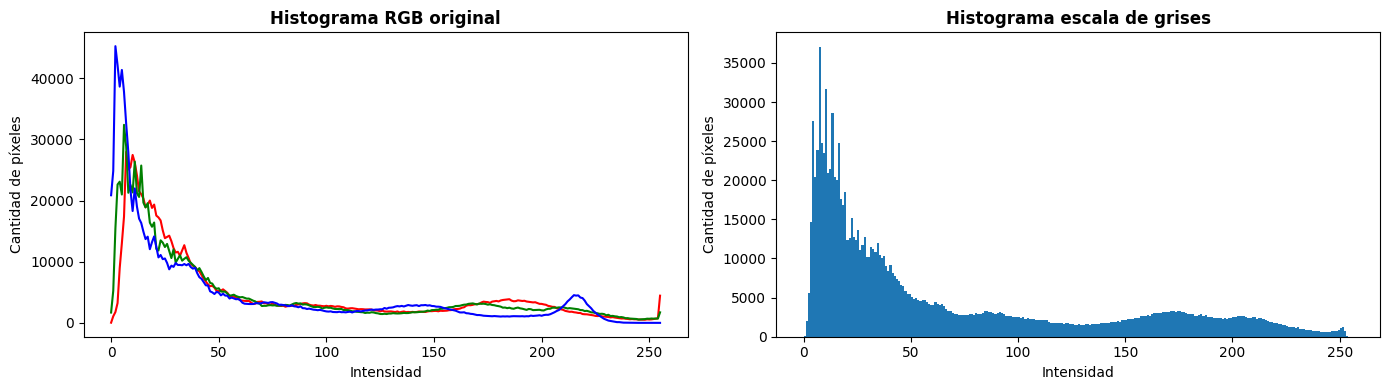

In [9]:
plt.figure(figsize=(14, 4))


# Histograma RGB original
plt.subplot(1, 2, 1)

for i, color in enumerate(colores):

    histograma = cv2.calcHist(
        [imagen_simplicidad_rgb],
        [i],
        None,
        [256],
        [0, 256]
    )

    plt.plot(histograma, color=color)

plt.title("Histograma RGB original", fontweight="bold")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")


# Histograma escala de grises
plt.subplot(1, 2, 2)

plt.hist(
    imagen_simplicidad_gris.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title("Histograma escala de grises", fontweight="bold")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

La comparación entre histogramas permite analizar cómo cambia la distribución tonal de la imagen luego de eliminar la información cromática. Mientras el histograma RGB separa la intensidad por canales de color, el histograma en escala de grises concentra la información únicamente en niveles de luminosidad.

In [10]:
from google.colab import files

# Guardamos la imagen en escala de grises
cv2.imwrite(
    "gata_negra_escala_grises.jpg",
    imagen_simplicidad_gris
)

# Descarga directa
files.download("gata_negra_escala_grises.jpg")

print("Imagen exportada correctamente.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Imagen exportada correctamente.
